# Phương pháp Học tăng cường kết hợp học sâu để tăng đánh giá của agent trước khi đưa ra hành động

## Xử lý trước khi huấn luyện

### Hiểu khái niệm Vectorization

In [1]:
import time

# Tính tổng từ 1 đến 10,000,000 bằng vòng lặp truyền thống (Non-vectorized)
start = time.time()
total = 0
for i in range(1, 10000001):
    total += i
print(f"the sum is {total}")
end = time.time()
print(f"the calculation took {end - start:.6f} seconds to finish")

the sum is 50000005000000
the calculation took 0.931130 seconds to finish


In [2]:
import numpy as np
import time

# Tính tổng bằng kỹ thuật Vectorization qua NumPy matmul
start = time.time()
constant = np.ones(10000000)
numbers = np.arange(10000000) + 1
total = np.matmul(constant, numbers)
print(f"the sum is {total}")
end = time.time()
print(f"the calculation took {end - start:.6f} seconds to finish")

the sum is 50000005000000.0
the calculation took 0.191485 seconds to finish


### Kết hợp 2 mạng đầu vào của dữ liệu làm đầu vào cho hệ thống huấn luyện

- 1 networks là đầu vào thô 1 chiều với 9 neurons mỗi ô (Tức là đầu vào hành động của mạng là 1 trong 9 ô one-hot): Dense layer 9 Neurons Network
- 1 networks là mạng tích chập CNN để nhận diện bảng 2D của trò chơi: Convolutional Neurons Network

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_inputs = 9
num_actions = 9
num_hidden = 32

# 1. Đầu vào tích chập Conv2D (nhận diện cấu trúc không gian 2D 3x3x1)
conv_inputs = layers.Input(shape=(3, 3, 1))
conv = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same",
                     input_shape=(3, 3, 1), activation="relu")(conv_inputs)
flat = layers.Flatten()(conv)

# 2. Đầu vào Dense (vector thô 9 phần tử)
inputs = layers.Input(shape=(9,))

# Kết hợp 2 nhánh đầu vào thành 1 tensor duy nhất
two_inputs = tf.concat([flat, inputs], axis=1)

# Hai lớp ẩn Dense trích xuất đặc trưng
common = layers.Dense(128, activation="relu")(two_inputs)
action = layers.Dense(32, activation="relu")(common)

# Policy output layer (9 hành động với Softmax phân phối xác suất)
action = layers.Dense(num_actions, activation="softmax")(action)

# Khởi tạo mô hình hai đầu vào (Dual-Input Network)
model = keras.Model(inputs=[inputs, conv_inputs], outputs=action)
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 3, 3, 1)]    0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 3, 3, 64)     640         ['input_1[0][0]']                
                                                                                                  
 flatten (Flatten)              (None, 576)          0           ['conv2d[0][0]']                 
                                                                                                  
 input_2 (InputLayer)           [(None, 9)]          0           []                               
                                                                                              

## Cho chơi với Strong Policy Network

### Truyền checkpoint Strong Policy Network

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Tìm file checkpoint strong_ttt.h5 với đường dẫn dự phòng
STRONG_MODEL_PATHS = [
    "files/strong_ttt.h5",
    "../files/strong_ttt.h5",
    "practice/TicTacToe_framework/files/strong_ttt.h5"
]
strong_path = None
for p in STRONG_MODEL_PATHS:
    if os.path.exists(p):
        strong_path = p
        break

if strong_path is None:
    raise FileNotFoundError(f"Không tìm thấy file strong_ttt.h5 trong: {STRONG_MODEL_PATHS}")

trained = keras.models.load_model(strong_path)
print(f"✅ Đã tải checkpoint Strong Policy Network thành công từ: {strong_path}")

# Định nghĩa đối thủ Strong Policy Agent (Chapter 14)
def opponent(env):
    state = env.state.reshape(-1, 3, 3, 1)
    if env.turn == "X":
        action_probs = trained(state, training=False)
    else:
        action_probs = trained(-state, training=False)
    
    aps = []
    valid_moves = sorted(env.validinputs)
    for a in valid_moves:
        aps.append(float(np.squeeze(action_probs)[a - 1]))
    
    prob_sum = sum(aps)
    if prob_sum > 0:
        ps = np.array(aps) / prob_sum
        return np.random.choice(valid_moves, p=ps)
    return env.sample()

✅ Đã tải checkpoint Strong Policy Network thành công từ: files/strong_ttt.h5


### Huấn luyện mô hình để chơi người chơi X

In [5]:
import sys
import os
from copy import deepcopy

# Đảm bảo nạp đúng môi trường ttt từ thư mục utils
for path in [".", "..", "practice/TicTacToe_framework"]:
    if os.path.exists(os.path.join(path, "utils", "ttt_simple_env.py")) and path not in sys.path:
        sys.path.insert(0, path)

from utils.ttt_simple_env import ttt

max_steps = 50
env = ttt()

def playing_X():
    # Khởi tạo các danh sách ghi lại lịch sử ván cờ
    action_probs_history = []
    wrongmoves_history = []
    rewards_history = []
    state = env.reset()
    episode_reward = 0
    states = []
    
    for step in range(max_steps):
        state = state.reshape(-1, 9)
        conv_state = state.reshape(-1, 3, 3, 1)
        # Dự đoán xác suất từ mạng policy dual-input
        action_probs = model([state, conv_state], training=False)
        action = np.random.choice(num_actions, p=np.squeeze(action_probs.numpy()))
        action_probs_history.append(tf.math.log(action_probs[0, action]))
        
        # Phạt nếu agent chọn nước đi không hợp lệ
        if action + 1 not in env.validinputs:
            rewards_history.append(0)
            wrongmoves_history.append(-1)
        else:
            # Thực hiện nước đi hợp lệ
            state, reward, done, _ = env.step(action + 1)
            states.append(state)
            if done:
                wrongmoves_history.append(0)
                rewards_history.append(reward)
                episode_reward += reward
                break
            else:
                state, reward, done, _ = env.step(opponent(env))
                rewards_history.append(reward)
                wrongmoves_history.append(0)
                episode_reward += reward
                if done:
                    break
                    
    return action_probs_history, wrongmoves_history, rewards_history, episode_reward, states, reward

### Huấn luyện mô hình để chơi người chơi O

In [6]:
def playing_O():
    action_probs_history = []
    wrongmoves_history = []
    rewards_history = []
    state = env.reset()
    episode_reward = 0
    states = []
    
    # Đối thủ (quân X) đi trước
    state, reward, done, _ = env.step(opponent(env))
    
    for step in range(max_steps):
        state = state.reshape(-1, 9)
        conv_state = state.reshape(-1, 3, 3, 1)
        # Nhân bảng cờ với -1 để tạo góc nhìn độc lập người chơi (Player-Independent Encoding)
        action_probs = model([-state, -conv_state], training=False)
        action = np.random.choice(num_actions, p=np.squeeze(action_probs.numpy()))
        action_probs_history.append(tf.math.log(action_probs[0, action]))
        
        # Phạt nếu agent chọn nước đi không hợp lệ
        if action + 1 not in env.validinputs:
            rewards_history.append(0)
            wrongmoves_history.append(-1)
        else:
            state, reward, done, _ = env.step(action + 1)
            states.append(-state)
            if done:
                wrongmoves_history.append(0)
                rewards_history.append(-reward)
                episode_reward += -reward
                break
            else:
                state, reward, done, _ = env.step(opponent(env))
                rewards_history.append(-reward)
                wrongmoves_history.append(0)
                episode_reward += -reward
                if done:
                    break
                    
    return action_probs_history, wrongmoves_history, rewards_history, episode_reward, states, -reward

### Định nghĩa hàm phần thưởng

In [7]:
gamma = 0.95

def discount_rs(r, wrong):
    """
    Chiết khấu phần thưởng tương lai cho các nước đi hợp lệ.
    Các nước đi phạm luật (wrong == -1) không được tính chiết khấu.
    """
    discounted_rs = np.zeros(len(r))
    running_add = 0
    for i in reversed(range(0, len(r))):
        if wrong[i] == 0:
            running_add = gamma * running_add + r[i]
            discounted_rs[i] = running_add
    return discounted_rs.tolist()

### Bắt đầu huấn luyện

Batch lưu trữ huấn luyện người chơi X

In [8]:
batch_size = 10
allstates = []
alloutcome = []

def create_batch_X(batch_size):
    action_probs_history = []
    wrongmoves_history = []
    rewards_history = []
    episode_rewards = []
    for i in range(batch_size):
        aps, wms, rs, er, ss, outcome = playing_X()
        returns = discount_rs(rs, wms)
        action_probs_history += aps
        wrongmoves_history += wms
        combined = np.array(returns) + np.array(wms)
        rewards_history += combined.tolist()
        episode_rewards.append(er)
        # Ghi nhận trạng thái và kết quả ván đấu phục vụ huấn luyện Value Network
        allstates.append(ss)
        alloutcome.append(outcome)
    return action_probs_history, rewards_history, episode_rewards

Batch lưu trữ huấn luyện người chơi O

In [9]:
def create_batch_O(batch_size):
    action_probs_history = []
    wrongmoves_history = []
    rewards_history = []
    episode_rewards = []
    for i in range(batch_size):
        aps, wms, rs, er, ss, outcome = playing_O()
        returns = discount_rs(rs, wms)
        action_probs_history += aps
        wrongmoves_history += wms
        combined = np.array(returns) + np.array(wms)
        rewards_history += combined.tolist()
        episode_rewards.append(er)
        allstates.append(ss)
        alloutcome.append(outcome)
    return action_probs_history, rewards_history, episode_rewards

Vòng lặp huấn luyện

In [10]:
from collections import deque
import pickle
import os

os.makedirs("files", exist_ok=True)
running_rewards = deque(maxlen=100)
episode_count = 0
batches = 0

print("🚀 Bắt đầu quá trình huấn luyện Policy Gradient (Self-Play xen kẽ X và O)...")
while True:
    with tf.GradientTape() as tape:
        if batches % 2 == 0:
            action_probs_history, rewards_history, episode_rewards = create_batch_X(batch_size)
        else:
            action_probs_history, rewards_history, episode_rewards = create_batch_O(batch_size)

        rets = tf.convert_to_tensor(rewards_history, dtype=tf.float32)
        alosses = -tf.multiply(tf.convert_to_tensor(action_probs_history, dtype=tf.float32), rets)
        loss_value = tf.reduce_sum(alosses)

    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    episode_count += batch_size
    batches += 1
    running_rewards += episode_rewards
    running_reward = np.mean(np.array(running_rewards))

    if episode_count % 1000 == 0:
        template = "running reward: {:.6f} at episode {}"
        print(template.format(running_reward, episode_count))

    # Dừng khi đạt điều kiện giải quyết xong hoặc đạt ngưỡng an toàn
    if min(running_rewards) >= 0 and episode_count > 100:
        print(f"🎉 Bài toán được giải quyết tại episode {episode_count}!")
        break
    if episode_count >= 20000:
        print("Đã hoàn thành 20000 episodes huấn luyện Policy Gradient.")
        break

model.save("files/pg_ttt.h5")
print("💾 Đã lưu Policy Gradient Model tại: files/pg_ttt.h5")

with open("files/PG_games_ttt.p", "wb") as f:
    pickle.dump((allstates, alloutcome), f)
print(f"💾 Đã lưu {len(allstates)} ván cờ kinh nghiệm tại: files/PG_games_ttt.p")

🚀 Bắt đầu quá trình huấn luyện Policy Gradient (Self-Play xen kẽ X và O)...
running reward: -0.920000 at episode 1000
running reward: -0.810000 at episode 2000
running reward: -0.830000 at episode 3000
running reward: -0.920000 at episode 4000
running reward: -0.820000 at episode 5000
running reward: -0.810000 at episode 6000
running reward: -0.790000 at episode 7000
running reward: -0.740000 at episode 8000
running reward: -0.680000 at episode 9000
running reward: -0.690000 at episode 10000
running reward: -0.650000 at episode 11000
running reward: -0.630000 at episode 12000
running reward: -0.570000 at episode 13000
running reward: -0.530000 at episode 14000
running reward: -0.490000 at episode 15000
running reward: -0.430000 at episode 16000
running reward: -0.510000 at episode 17000
running reward: -0.420000 at episode 18000
running reward: -0.410000 at episode 19000
running reward: -0.450000 at episode 20000
Đã hoàn thành 20000 episodes huấn luyện Policy Gradient.
💾 Đã lưu Policy 

## Huấn luyện Value Network trong Tic Tac Toe

### Nạp kinh nghiệm chơi self-play của PG 

In [11]:
import pickle
import os
import numpy as np

# Nạp file PG_games_ttt.p với đường dẫn dự phòng
PG_GAMES_PATH = "files/PG_games_ttt.p"
if not os.path.exists(PG_GAMES_PATH):
    for alt in ["../files/PG_games_ttt.p", "practice/TicTacToe_framework/files/PG_games_ttt.p"]:
        if os.path.exists(alt):
            PG_GAMES_PATH = alt
            break

with open(PG_GAMES_PATH, "rb") as f:
    history, results = pickle.load(f)

Xs = []
ys = []
for states, result in zip(history, results):
    for state in states:
        Xs.append(state)
        if result == 1:
            ys.append(np.array([0, 1, 0]))  # Thắng
        elif result == -1:
            ys.append(np.array([0, 0, 1]))  # Thua
        elif result == 0:
            ys.append(np.array([1, 0, 0]))  # Hòa

Xs = np.array(Xs).reshape(-1, 3, 3, 1)
ys = np.array(ys).reshape(-1, 3)

print(f"✅ Đã xử lý dữ liệu huấn luyện Value Network: Xs shape = {Xs.shape}, ys shape = {ys.shape}")

✅ Đã xử lý dữ liệu huấn luyện Value Network: Xs shape = (67696, 3, 3, 1), ys shape = (67696, 3)


### Chạy và huấn luyện Value Network cho TicTacToe

In [12]:
from tensorflow.keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.models import Sequential
from copy import deepcopy
import os

# Khởi tạo cấu trúc Value Network theo đúng Chapter 14
value_model = Sequential()
value_model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same",
                       activation="relu", input_shape=(3, 3, 1)))
value_model.add(Flatten())
value_model.add(Dense(units=64, activation="relu"))
value_model.add(Dense(units=64, activation="relu"))
value_model.add(Dense(3, activation="softmax"))

value_model.compile(loss="categorical_crossentropy",
                    optimizer="adam",
                    metrics="accuracy")

print("🚀 Bắt đầu huấn luyện Value Network (50 epochs)...")
value_model.fit(Xs, ys, epochs=50, verbose=1)

os.makedirs("files", exist_ok=True)
value_model.save("files/value_ttt.h5")
print("💾 Đã lưu checkpoint Value Network tại: files/value_ttt.h5")

# Chiến lược chọn nước đi tốt nhất dựa trên Value Network (Chapter 14)
def best_move(env):
    bestoutcome = -2.0
    bestmove = None
    for move in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, info = env_copy.step(move)
        state = state.reshape(-1, 3, 3, 1)
        if env.turn == "X":
            ps = value_model(state, training=False).numpy()
        else:
            ps = value_model(-state, training=False).numpy()
        
        # win_lose_dif = prob(win) - prob(lose)
        win_lose_dif = float(ps[0][1] - ps[0][2])
        if win_lose_dif > bestoutcome:
            bestoutcome = win_lose_dif
            bestmove = move
    return bestmove

🚀 Bắt đầu huấn luyện Value Network (50 epochs)...
Epoch 1/50
2116/2116 [==============================] - 4s 2ms/step - loss: 0.1710 - accuracy: 0.9351
Epoch 2/50
2116/2116 [==============================] - 3s 2ms/step - loss: 0.1239 - accuracy: 0.9503
Epoch 3/50
2116/2116 [==============================] - 3s 2ms/step - loss: 0.1160 - accuracy: 0.9515
Epoch 4/50
2116/2116 [==============================] - 3s 1ms/step - loss: 0.1119 - accuracy: 0.9529
Epoch 5/50
2116/2116 [==============================] - 3s 1ms/step - loss: 0.1090 - accuracy: 0.9535
Epoch 6/50
2116/2116 [==============================] - 3s 1ms/step - loss: 0.1072 - accuracy: 0.9551
Epoch 7/50
2116/2116 [==============================] - 3s 2ms/step - loss: 0.1057 - accuracy: 0.9548
Epoch 8/50
2116/2116 [==============================] - 3s 2ms/step - loss: 0.1042 - accuracy: 0.9552
Epoch 9/50
2116/2116 [==============================] - 3s 1ms/step - loss: 0.1038 - accuracy: 0.9557
Epoch 10/50
2116/2116 [=========

## Thử nghiệm chơi vòng tròn giữa các mô hình

perfectTTT

In [13]:
# =============================================================================
# ĐẤU THỦ 1: perfectTTT (Bộ 8 luật Newell & Simon 1972)
# =============================================================================
LINES = [
    (1, 2, 3), (4, 5, 6), (7, 8, 9),
    (1, 4, 7), (2, 5, 8), (3, 6, 9),
    (1, 5, 9), (3, 5, 7)
]

def count_threats(state, piece):
    threats = 0
    for a, b, c in LINES:
        line = [state[a - 1], state[b - 1], state[c - 1]]
        if line.count(piece) == 2 and line.count(0) == 1:
            threats += 1
    return threats

def perfectTTT(env):
    my_piece = 1 if env.turn == 'X' else -1
    opp_piece = -my_piece
    valid = env.validinputs

    # Luật 1: Thắng ngay nếu có 3 ô thẳng hàng
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = my_piece
        for a, b, c in LINES:
            if tmp[a - 1] == tmp[b - 1] == tmp[c - 1] == my_piece:
                return m

    # Luật 2: Chặn đối thủ thắng ngay
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = opp_piece
        for a, b, c in LINES:
            if tmp[a - 1] == tmp[b - 1] == tmp[c - 1] == opp_piece:
                return m

    # Luật 3: Tạo thế gọng kìm (Fork)
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = my_piece
        if count_threats(tmp, my_piece) >= 2:
            return m

    # Luật 4: Chặn thế gọng kìm của đối thủ (Block Fork)
    opp_fork_cells = []
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = opp_piece
        if count_threats(tmp, opp_piece) >= 2:
            opp_fork_cells.append(m)
    if opp_fork_cells:
        for m in valid:
            tmp = env.state.copy()
            tmp[m - 1] = my_piece
            for a, b, c in LINES:
                line_cells = [a, b, c]
                line_vals = [tmp[x - 1] for x in line_cells]
                if line_vals.count(my_piece) == 2 and line_vals.count(0) == 1:
                    def_cell = line_cells[line_vals.index(0)]
                    if def_cell not in opp_fork_cells:
                        return m
        return opp_fork_cells[0]

    # Luật 5: Chiếm ô trung tâm (ô số 5)
    if 5 in valid:
        return 5

    # Luật 6: Chiếm ô góc đối diện với góc đối thủ
    for opp_c, my_c in [(1, 9), (9, 1), (3, 7), (7, 3)]:
        if env.state[opp_c - 1] == opp_piece and my_c in valid:
            return my_c

    # Luật 7: Chiếm ô góc trống
    corners = [c for c in [1, 3, 7, 9] if c in valid]
    if corners:
        return corners[0]

    # Luật 8: Chiếm ô cạnh trống
    sides = [s for s in [2, 4, 6, 8] if s in valid]
    if sides:
        return sides[0]

    return valid[0]

print("✅ Đã khởi tạo hoàn tất mô hình perfectTTT!")

✅ Đã khởi tạo hoàn tất mô hình perfectTTT!


MiniMax_ab

In [14]:
# =============================================================================
# ĐẤU THỦ 2: MiniMax_ab (Cắt tỉa Alpha-Beta Pruning theo Chapter 6)
# =============================================================================
from copy import deepcopy
import random

def maximized_payoff_ttt(env, reward, done, alpha, beta):
    if done:
        return -1 if reward != 0 else 0
    if alpha is None:
        alpha = -2
    if beta is None:
        beta = -2

    best_payoff = alpha if env.turn == "X" else beta
    for m in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, info = env_copy.step(m)
        opponent_payoff = maximized_payoff_ttt(env_copy, reward, done, alpha, beta)
        my_payoff = -opponent_payoff
        if my_payoff > best_payoff:
            best_payoff = my_payoff
            if env.turn == "X":
                alpha = best_payoff
            if env.turn == "O":
                beta = best_payoff
        if alpha >= -beta:
            break
    return best_payoff

def MiniMax_ab(env):
    wins = []
    ties = []
    losses = []
    for m in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, info = env_copy.step(m)
        if done and reward != 0:
            return m
        opponent_payoff = maximized_payoff_ttt(env_copy, reward, done, -2, -2)
        my_payoff = -opponent_payoff
        if my_payoff == 1:
            wins.append(m)
        elif my_payoff == 0:
            ties.append(m)
        else:
            losses.append(m)

    if len(wins) > 0:
        return random.choice(wins)
    elif len(ties) > 0:
        return random.choice(ties)
    return env.sample()

print("✅ Đã khởi tạo hoàn tất mô hình MiniMax_ab!")

✅ Đã khởi tạo hoàn tất mô hình MiniMax_ab!


MCTS_200_rollouts

In [15]:
# =============================================================================
# ĐẤU THỦ 3: MCTS_200_rollouts (Monte Carlo Tree Search với 200 Rollouts)
# =============================================================================
from copy import deepcopy
from math import sqrt, log
import random

def mcts_select(env, counts, wins, losses, temperature=1.414):
    for k in env.validinputs:
        if counts[k] == 0:
            return k
    N = sum(counts.values())
    scores = {}
    for k in env.validinputs:
        vi = (wins.get(k, 0) - losses.get(k, 0)) / counts[k]
        exploration = temperature * sqrt(log(N) / counts[k])
        scores[k] = vi + exploration
    return max(scores, key=scores.get)

def mcts_expand(env, move):
    env_copy = deepcopy(env)
    state, reward, done, info = env_copy.step(move)
    return env_copy, done, reward

def mcts_simulate(env_copy, done, reward):
    if done:
        return reward
    while True:
        move = env_copy.sample()
        state, reward, done, info = env_copy.step(move)
        if done:
            return reward

def mcts_backpropagate(env, move, reward, counts, wins, losses):
    counts[move] = counts.get(move, 0) + 1
    if reward == 1 and env.turn == "X":
        wins[move] = wins.get(move, 0) + 1
    elif reward == -1 and env.turn == "O":
        wins[move] = wins.get(move, 0) + 1
    elif reward == -1 and env.turn == "X":
        losses[move] = losses.get(move, 0) + 1
    elif reward == 1 and env.turn == "O":
        losses[move] = losses.get(move, 0) + 1
    return counts, wins, losses

def mcts_next_best_move(counts, wins, losses):
    scores = {}
    for k, v in counts.items():
        if v == 0:
            scores[k] = -float('inf')
        else:
            scores[k] = (wins.get(k, 0) - losses.get(k, 0)) / v
    return max(scores, key=scores.get)

def MCTS_200_rollouts(env, num_rollouts=200, temperature=1.414):
    if len(env.validinputs) == 1:
        return env.validinputs[0]

    counts = {m: 0 for m in env.validinputs}
    wins = {m: 0 for m in env.validinputs}
    losses = {m: 0 for m in env.validinputs}

    for _ in range(num_rollouts):
        move = mcts_select(env, counts, wins, losses, temperature)
        env_copy, done, reward = mcts_expand(env, move)
        reward = mcts_simulate(env_copy, done, reward)
        counts, wins, losses = mcts_backpropagate(env, move, reward, counts, wins, losses)

    return mcts_next_best_move(counts, wins, losses)

print("✅ Đã khởi tạo hoàn tất mô hình MCTS_200_rollouts!")

✅ Đã khởi tạo hoàn tất mô hình MCTS_200_rollouts!


Fast & Strong Policy Network (Nạp checkpoint)

In [16]:
# =============================================================================
# ĐẤU THỦ 4 & 5: Fast_Policy_Network & Strong_Policy_Network (Nạp Checkpoints)
# =============================================================================
import os
import numpy as np
from tensorflow.keras.models import load_model

def get_model_path(filename):
    for candidate in [
        os.path.join("files", filename),
        os.path.join("..", "files", filename),
        os.path.join("practice", "TicTacToe_framework", "files", filename)
    ]:
        if os.path.exists(candidate):
            return candidate
    return None

fast_path = get_model_path("fast_ttt.h5")
strong_path = get_model_path("strong_ttt.h5")

if fast_path is None or strong_path is None:
    raise FileNotFoundError(f"Không tìm thấy checkpoint policy. fast={fast_path}, strong={strong_path}")

fast_policy_model = load_model(fast_path)
strong_policy_model = load_model(strong_path)

print(f"✅ Đã nạp thành công Fast Policy Network từ: {fast_path}")
print(f"✅ Đã nạp thành công Strong Policy Network từ: {strong_path}")

def Fast_Policy_Network(env):
    state = env.state.reshape(-1, 3, 3, 1)
    input_state = state if env.turn == "X" else -state
    probs = fast_policy_model(input_state, training=False).numpy().flatten()
    return max(env.validinputs, key=lambda m: probs[m - 1])

def Strong_Policy_Network(env):
    state = env.state.reshape(-1, 3, 3, 1)
    input_state = state if env.turn == "X" else -state
    probs = strong_policy_model(input_state, training=False).numpy().flatten()
    return max(env.validinputs, key=lambda m: probs[m - 1])

✅ Đã nạp thành công Fast Policy Network từ: files\fast_ttt.h5
✅ Đã nạp thành công Strong Policy Network từ: files\strong_ttt.h5


Q-learning

In [17]:
# =============================================================================
# ĐẤU THỦ 6: Q-learning (Nạp bảng Q-table từ file q_table_ttt_100000.p)
# =============================================================================
import pickle
import os
import numpy as np
import random

def get_q_path(filename):
    for candidate in [
        os.path.join("files", filename),
        os.path.join("..", "files", filename),
        os.path.join("practice", "TicTacToe_framework", "files", filename)
    ]:
        if os.path.exists(candidate):
            return candidate
    return None
q_path = get_q_path("q_table_ttt_100000.p")
if q_path is None:
    raise FileNotFoundError("Không tìm thấy file q_table_ttt_100000.p!")

with open(q_path, "rb") as fp:
    Q_table = pickle.load(fp)

print(f"✅ Đã nạp thành công Q-table từ: {q_path} ({len(Q_table)} trạng thái)!")

def Q_learning(env):
    turn_mult = 1 if env.turn == "X" else -1
    state_key = tuple(env.state * turn_mult)
    q_vals = Q_table.get(state_key, np.zeros(9, dtype=np.float32))
    valid_q = {m: q_vals[m - 1] for m in env.validinputs}
    max_q = max(valid_q.values())
    best_moves = [m for m, val in valid_q.items() if val == max_q]
    return random.choice(best_moves)

✅ Đã nạp thành công Q-table từ: files\q_table_ttt_100000.p (4520 trạng thái)!


Mix_MCTS_v1

In [18]:
# =============================================================================
# ĐẤU THỦ 7: Mix_MCTS_v1 (Strong Policy cho Selection + Rollout ngẫu nhiên - Chương 10)
# =============================================================================
from copy import deepcopy
from math import sqrt, log
import numpy as np
import os
from tensorflow.keras.models import load_model

# Đảm bảo Strong Policy Network sẵn sàng
if 'strong_policy_model' not in globals() or strong_policy_model is None:
    s_path = get_model_path("strong_ttt.h5") if 'get_model_path' in globals() else "files/strong_ttt.h5"
    if s_path and os.path.exists(s_path):
        strong_policy_model = load_model(s_path)
        print(f"✅ Đã nạp Strong Policy Network từ: {s_path}")

# Công thức UCT tích hợp Policy xác suất tiên nghiệm P(s, a) (Chương 10)
def mix_select(env, ps, counts, wins, losses, temperature=1.414, gamma=10):
    for k in env.validinputs:
        if counts[k] == 0:
            return k
    N = sum(counts.values())
    scores = {}
    for k in env.validinputs:
        weighted_pi = gamma * ps[k] / (1 + counts[k])
        vi = (wins.get(k, 0) - losses.get(k, 0)) / counts[k]
        exploration = temperature * sqrt(log(N) / counts[k])
        scores[k] = vi + exploration + weighted_pi
    return max(scores, key=scores.get)

def next_move_policy(ps, counts, wins, losses, gamma=10):
    scores = {}
    for k, v in counts.items():
        weighted_pi = gamma * ps[k] / (1 + counts[k])
        vi = (wins.get(k, 0) - losses.get(k, 0)) / v if v > 0 else 0
        scores[k] = vi + weighted_pi
    return max(scores, key=scores.get)

def Mix_MCTS_v1(env, num_rollouts=150, temperature=1.414, gamma=10):
    if len(env.validinputs) == 1:
        return env.validinputs[0]

    counts = {m: 0 for m in env.validinputs}
    wins = {m: 0 for m in env.validinputs}
    losses = {m: 0 for m in env.validinputs}

    # 1. Dự đoán phân phối xác suất từ Strong Policy Network
    state = env.state.reshape(-1, 3, 3, 1)
    input_state = state if env.turn == "X" else -state
    action_probs = strong_policy_model(input_state, training=False).numpy()
    ps = {a: float(np.squeeze(action_probs)[a - 1]) for a in env.validinputs}

    # 2. Chạy mô phỏng Rollouts (Selection có Policy tiên nghiệm, Simulation ngẫu nhiên)
    for _ in range(num_rollouts):
        move = mix_select(env, ps, counts, wins, losses, temperature, gamma)
        env_copy, done, reward = mcts_expand(env, move)
        reward = mcts_simulate(env_copy, done, reward)
        counts, wins, losses = mcts_backpropagate(env, move, reward, counts, wins, losses)

    return next_move_policy(ps, counts, wins, losses, gamma)

print("✅ Đã khởi tạo hoàn tất mô hình Mix_MCTS_v1!")

✅ Đã khởi tạo hoàn tất mô hình Mix_MCTS_v1!


## Các tác nhân chơi cùng nhau bao gồm:
- perfectTTT
- MiniMax_ab
- MCTS_200_rollouts
- Fast_Policy_Network
- Strong_Policy_Network
- Q-learning
- Value Network
- Mix_MCTS_v1

2 mô hình đánh với nhau 100 trận, 50 trận đi X và 50 trận đi O
--> Các bảng kết quả cần có: Grid tỉ lệ thắng của các mô hình với các mô hình khác khi đi X, Grid tỉ lệ thắng của các mô hình với các mô hình khác khi đi Y, Bảng thời gian đưa ra trung bình mỗi nước đi của các mô hình, Bảng thời gian mỗi trận của các mô hình.

🏁 KHỞI TRANH GIẢI ĐẤU VÒNG TRÒN: 8 MÔ HÌNH (2800 VÁN ĐẤU)
📌 Thể thức: 100 ván / cặp (50 ván cầm quân X - 50 ván cầm quân O)
[01/56] ⚔️  perfectTTT (X) vs MiniMax_ab (O) - Đang đấu 50 ván... Xong (18.2s) -> X Thắng: 0 | Hòa: 50 | O Thắng: 0
[02/56] ⚔️  perfectTTT (X) vs MCTS_200_rollouts (O) - Đang đấu 50 ván... Xong (2.3s) -> X Thắng: 32 | Hòa: 18 | O Thắng: 0
[03/56] ⚔️  perfectTTT (X) vs Fast_Policy_Network (O) - Đang đấu 50 ván... Xong (0.5s) -> X Thắng: 0 | Hòa: 50 | O Thắng: 0
[04/56] ⚔️  perfectTTT (X) vs Strong_Policy_Network (O) - Đang đấu 50 ván... Xong (0.5s) -> X Thắng: 0 | Hòa: 50 | O Thắng: 0
[05/56] ⚔️  perfectTTT (X) vs Q-learning (O) - Đang đấu 50 ván... Xong (0.0s) -> X Thắng: 0 | Hòa: 50 | O Thắng: 0
[06/56] ⚔️  perfectTTT (X) vs Value Network (O) - Đang đấu 50 ván... Xong (2.3s) -> X Thắng: 0 | Hòa: 50 | O Thắng: 0
[07/56] ⚔️  perfectTTT (X) vs Mix_MCTS_v1 (O) - Đang đấu 50 ván... Xong (2.6s) -> X Thắng: 8 | Hòa: 42 | O Thắng: 0
[08/56] ⚔️  MiniMax_ab (X) vs perfectT

,Mô hình (Quân X),perfectTTT,MiniMax_ab,MCTS_200_rollouts,Fast_Policy_Network,Strong_Policy_Network,Q-learning,Value Network,Mix_MCTS_v1,Tổng Thắng,Tổng Hòa,Tổng Thua,Tỉ lệ Thắng (%)
0,perfectTTT,—,0W-50D-0L,32W-18D-0L,0W-50D-0L,0W-50D-0L,0W-50D-0L,0W-50D-0L,8W-42D-0L,40,310,0,11.4
1,MiniMax_ab,0W-50D-0L,—,30W-20D-0L,1W-49D-0L,0W-50D-0L,7W-43D-0L,9W-41D-0L,16W-34D-0L,63,287,0,18.0
2,MCTS_200_rollouts,0W-50D-0L,0W-50D-0L,—,2W-48D-0L,0W-48D-2L,6W-43D-1L,4W-46D-0L,4W-45D-1L,16,330,4,4.6
3,Fast_Policy_Network,0W-50D-0L,0W-50D-0L,35W-15D-0L,—,0W-50D-0L,50W-0D-0L,0W-50D-0L,16W-34D-0L,101,249,0,28.9
4,Strong_Policy_Network,0W-50D-0L,0W-50D-0L,39W-11D-0L,0W-50D-0L,—,50W-0D-0L,0W-50D-0L,14W-36D-0L,103,247,0,29.4
5,Q-learning,0W-50D-0L,0W-50D-0L,43W-7D-0L,0W-50D-0L,0W-50D-0L,—,0W-50D-0L,18W-32D-0L,61,289,0,17.4
6,Value Network,0W-0D-50L,0W-10D-40L,29W-3D-18L,0W-0D-50L,0W-0D-50L,0W-50D-0L,—,10W-9D-31L,39,72,239,11.1
7,Mix_MCTS_v1,0W-50D-0L,0W-50D-0L,23W-27D-0L,0W-50D-0L,0W-50D-0L,7W-43D-0L,4W-46D-0L,—,34,316,0,9.7



📊 2. GRID TỈ LỆ THẮNG CỦA CÁC MÔ HÌNH KHI ĐI SAU (QUÂN O / Y)


,Mô hình (Quân O),perfectTTT,MiniMax_ab,MCTS_200_rollouts,Fast_Policy_Network,Strong_Policy_Network,Q-learning,Value Network,Mix_MCTS_v1,Tổng Thắng,Tổng Hòa,Tổng Thua,Tỉ lệ Thắng (%)
0,perfectTTT,—,0W-50D-0L,0W-50D-0L,0W-50D-0L,0W-50D-0L,0W-50D-0L,50W-0D-0L,0W-50D-0L,50,300,0,14.3
1,MiniMax_ab,0W-50D-0L,—,0W-50D-0L,0W-50D-0L,0W-50D-0L,0W-50D-0L,40W-10D-0L,0W-50D-0L,40,310,0,11.4
2,MCTS_200_rollouts,0W-18D-32L,0W-20D-30L,—,0W-15D-35L,0W-11D-39L,0W-7D-43L,18W-3D-29L,0W-27D-23L,18,101,231,5.1
3,Fast_Policy_Network,0W-50D-0L,0W-49D-1L,0W-48D-2L,—,0W-50D-0L,0W-50D-0L,50W-0D-0L,0W-50D-0L,50,297,3,14.3
4,Strong_Policy_Network,0W-50D-0L,0W-50D-0L,2W-48D-0L,0W-50D-0L,—,0W-50D-0L,50W-0D-0L,0W-50D-0L,52,298,0,14.9
5,Q-learning,0W-50D-0L,0W-43D-7L,1W-43D-6L,0W-0D-50L,0W-0D-50L,—,0W-50D-0L,0W-43D-7L,1,229,120,0.3
6,Value Network,0W-50D-0L,0W-41D-9L,0W-46D-4L,0W-50D-0L,0W-50D-0L,0W-50D-0L,—,0W-46D-4L,0,333,17,0.0
7,Mix_MCTS_v1,0W-42D-8L,0W-34D-16L,1W-45D-4L,0W-34D-16L,0W-36D-14L,0W-32D-18L,31W-9D-10L,—,32,232,86,9.1



⚡ 3. BẢNG THỜI GIAN ĐƯA RA TRUNG BÌNH MỖI NƯỚC ĐI CỦA CÁC MÔ HÌNH


,Mô hình,Thời gian TB/nước đi (ms),Độ lệch chuẩn (ms),Tổng số nước đi
5,Q-learning,0.022,0.011,2840
0,perfectTTT,0.063,0.047,3060
3,Fast_Policy_Network,2.292,0.240,2994
4,Strong_Policy_Network,2.667,0.264,2989
7,Mix_MCTS_v1,11.885,4.218,2971
2,MCTS_200_rollouts,12.224,4.533,2812
6,Value Network,12.536,5.323,2711
1,MiniMax_ab,246.402,522.068,3046



⏱️ 4. BẢNG THỜI GIAN TRUNG BÌNH MỖI TRẬN ĐẤU CỦA CÁC MÔ HÌNH


,Mô hình,Thời gian TB/trận (ms),Tốc độ chơi (trận/giây),Tổng số ván đấu
5,Q-learning,177.57,5.6,700
0,perfectTTT,178.09,5.6,700
3,Fast_Policy_Network,186.90,5.4,700
4,Strong_Policy_Network,187.25,5.3,700
2,MCTS_200_rollouts,217.75,4.6,700
6,Value Network,217.83,4.6,700
7,Mix_MCTS_v1,221.50,4.5,700
1,MiniMax_ab,1097.15,0.9,700


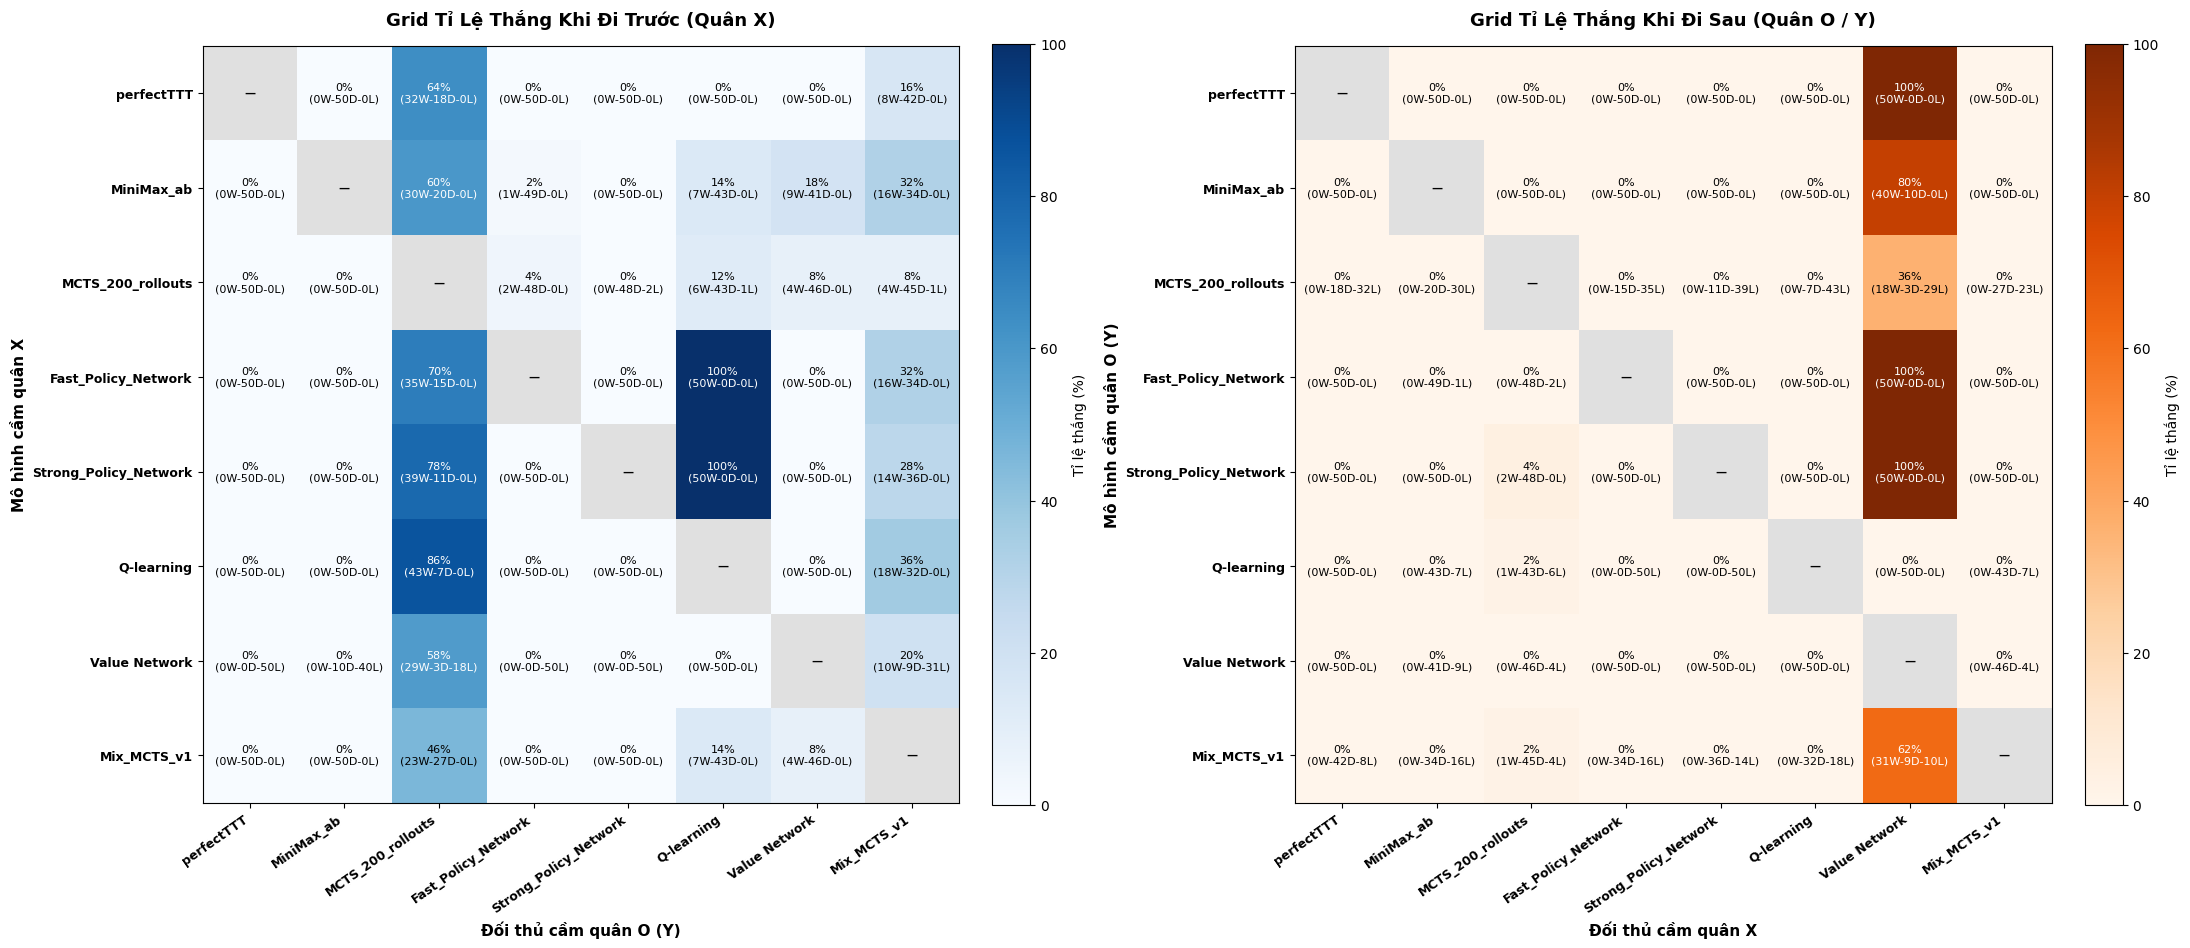

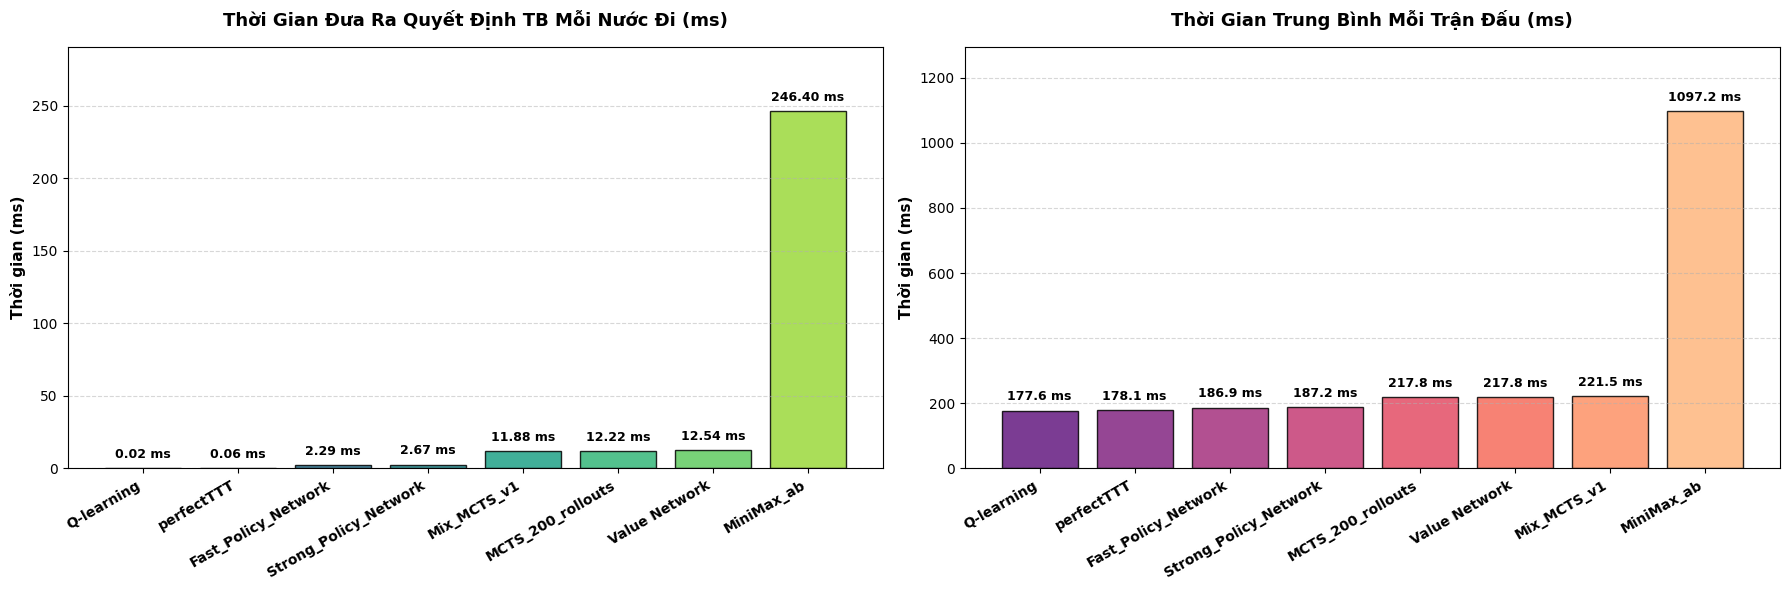

In [19]:
# =============================================================================
# GIẢI ĐẤU VÒNG TRÒN (ROUND-ROBIN) GIỮA 8 MÔ HÌNH AI TICTACTOE
# 100 ván / cặp (50 ván cầm quân X, 50 ván cầm quân O)
# =============================================================================
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Đảm bảo Value Network đã sẵn sàng
if 'value_model' not in globals() or value_model is None:
    v_path = get_model_path("value_ttt.h5") if 'get_model_path' in globals() else "files/value_ttt.h5"
    if v_path and os.path.exists(v_path):
        value_model = load_model(v_path)
        print(f"✅ Đã nạp Value Network từ {v_path}")

def Value_Network_agent(env):
    return best_move(env)

# Danh sách 8 mô hình tham gia giải đấu
tournament_models = {
    'perfectTTT': perfectTTT,
    'MiniMax_ab': MiniMax_ab,
    'MCTS_200_rollouts': MCTS_200_rollouts,
    'Fast_Policy_Network': Fast_Policy_Network,
    'Strong_Policy_Network': Strong_Policy_Network,
    'Q-learning': Q_learning,
    'Value Network': Value_Network_agent,
    'Mix_MCTS_v1': Mix_MCTS_v1
}

model_names = list(tournament_models.keys())
n_models = len(model_names)
N_GAMES_PER_SIDE = 50  # 50 ván đi trước (X), 50 ván đi sau (O) -> 100 ván / cặp

match_results = {m1: {m2: {'win': 0, 'tie': 0, 'loss': 0} for m2 in model_names if m2 != m1} for m1 in model_names}
perf_data = {
    m: {
        'move_times': [],
        'game_times': [],
        'games_played': 0
    } for m in model_names
}

total_pairs = n_models * (n_models - 1)
current_pair = 0

print("=" * 85)
print(f"🏁 KHỞI TRANH GIẢI ĐẤU VÒNG TRÒN: {n_models} MÔ HÌNH ({total_pairs * N_GAMES_PER_SIDE} VÁN ĐẤU)")
print("📌 Thể thức: 100 ván / cặp (50 ván cầm quân X - 50 ván cầm quân O)")
print("=" * 85)

t_start_tournament = time.time()

for i in range(n_models):
    for j in range(n_models):
        if i == j:
            continue
        m_x_name = model_names[i]
        m_o_name = model_names[j]
        current_pair += 1
        
        print(f"[{current_pair:02d}/{total_pairs:02d}] ⚔️  {m_x_name} (X) vs {m_o_name} (O) - Đang đấu {N_GAMES_PER_SIDE} ván...", end="", flush=True)
        t_pair_start = time.time()
        
        for game_idx in range(N_GAMES_PER_SIDE):
            env = ttt()
            env.reset()
            game_t0 = time.perf_counter()
            
            while True:
                # --- Lượt Player X ---
                t0 = time.perf_counter()
                act_x = tournament_models[m_x_name](env)
                t_move_x = time.perf_counter() - t0
                perf_data[m_x_name]['move_times'].append(t_move_x)
                
                _, reward, done, _ = env.step(act_x)
                if done:
                    g_dur = time.perf_counter() - game_t0
                    perf_data[m_x_name]['game_times'].append(g_dur)
                    perf_data[m_o_name]['game_times'].append(g_dur)
                    perf_data[m_x_name]['games_played'] += 1
                    perf_data[m_o_name]['games_played'] += 1
                    
                    if reward == 1:
                        match_results[m_x_name][m_o_name]['win'] += 1
                    elif reward == 0:
                        match_results[m_x_name][m_o_name]['tie'] += 1
                    else:
                        match_results[m_x_name][m_o_name]['loss'] += 1
                    break
                
                # --- Lượt Player O ---
                t0 = time.perf_counter()
                act_o = tournament_models[m_o_name](env)
                t_move_o = time.perf_counter() - t0
                perf_data[m_o_name]['move_times'].append(t_move_o)
                
                _, reward, done, _ = env.step(act_o)
                if done:
                    g_dur = time.perf_counter() - game_t0
                    perf_data[m_x_name]['game_times'].append(g_dur)
                    perf_data[m_o_name]['game_times'].append(g_dur)
                    perf_data[m_x_name]['games_played'] += 1
                    perf_data[m_o_name]['games_played'] += 1
                    
                    if reward == -1:
                        match_results[m_x_name][m_o_name]['loss'] += 1
                    elif reward == 0:
                        match_results[m_x_name][m_o_name]['tie'] += 1
                    else:
                        match_results[m_x_name][m_o_name]['win'] += 1
                    break
        
        pair_dur = time.time() - t_pair_start
        res = match_results[m_x_name][m_o_name]
        print(f" Xong ({pair_dur:.1f}s) -> X Thắng: {res['win']} | Hòa: {res['tie']} | O Thắng: {res['loss']}")

total_elapsed = time.time() - t_start_tournament
print("=" * 85)
print(f"🎉 GIẢI ĐẤU HOÀN TẤT! Tổng thời gian chạy: {total_elapsed:.2f} giây (~{total_elapsed/60:.2f} phút)")
print("=" * 85)

# =============================================================================
# 1. BẢNG GRID TỈ LỆ THẮNG KHI CẦM QUÂN X (ĐI TRƯỚC)
# =============================================================================
table_x_data = []
for mx in model_names:
    row = {'Mô hình (Quân X)': mx}
    total_w, total_t, total_l = 0, 0, 0
    for mo in model_names:
        if mx == mo:
            row[mo] = "—"
        else:
            w = match_results[mx][mo]['win']
            t = match_results[mx][mo]['tie']
            l = match_results[mx][mo]['loss']
            total_w += w
            total_t += t
            total_l += l
            row[mo] = f"{w}W-{t}D-{l}L"
    total_g = total_w + total_t + total_l
    row['Tổng Thắng'] = total_w
    row['Tổng Hòa'] = total_t
    row['Tổng Thua'] = total_l
    row['Tỉ lệ Thắng (%)'] = round((total_w / total_g) * 100, 1) if total_g > 0 else 0
    table_x_data.append(row)

df_win_grid_x = pd.DataFrame(table_x_data)

# =============================================================================
# 2. BẢNG GRID TỈ LỆ THẮNG KHI CẦM QUÂN O / Y (ĐI SAU)
# =============================================================================
table_o_data = []
for mo in model_names:
    row = {'Mô hình (Quân O)': mo}
    total_w, total_t, total_l = 0, 0, 0
    for mx in model_names:
        if mo == mx:
            row[mx] = "—"
        else:
            w = match_results[mx][mo]['loss']  # Quân O thắng
            t = match_results[mx][mo]['tie']
            l = match_results[mx][mo]['win']   # Quân O thua
            total_w += w
            total_t += t
            total_l += l
            row[mx] = f"{w}W-{t}D-{l}L"
    total_g = total_w + total_t + total_l
    row['Tổng Thắng'] = total_w
    row['Tổng Hòa'] = total_t
    row['Tổng Thua'] = total_l
    row['Tỉ lệ Thắng (%)'] = round((total_w / total_g) * 100, 1) if total_g > 0 else 0
    table_o_data.append(row)

df_win_grid_y = pd.DataFrame(table_o_data)

# =============================================================================
# 3. BẢNG THỜI GIAN ĐƯA RA TRUNG BÌNH MỖI NƯỚC ĐI
# =============================================================================
move_time_data = []
for m in model_names:
    move_times = perf_data[m]['move_times']
    avg_ms = np.mean(move_times) * 1000.0 if len(move_times) > 0 else 0
    std_ms = np.std(move_times) * 1000.0 if len(move_times) > 0 else 0
    move_time_data.append({
        'Mô hình': m,
        'Thời gian TB/nước đi (ms)': round(avg_ms, 3),
        'Độ lệch chuẩn (ms)': round(std_ms, 3),
        'Tổng số nước đi': len(move_times)
    })

df_avg_move_time = pd.DataFrame(move_time_data).sort_values(by='Thời gian TB/nước đi (ms)')

# =============================================================================
# 4. BẢNG THỜI GIAN TRUNG BÌNH MỖI TRẬN ĐẤU CỦA CÁC MÔ HÌNH
# =============================================================================
game_time_data = []
for m in model_names:
    game_times = perf_data[m]['game_times']
    avg_game_ms = np.mean(game_times) * 1000.0 if len(game_times) > 0 else 0
    gps = 1.0 / np.mean(game_times) if len(game_times) > 0 and np.mean(game_times) > 0 else 0
    game_time_data.append({
        'Mô hình': m,
        'Thời gian TB/trận (ms)': round(avg_game_ms, 2),
        'Tốc độ chơi (trận/giây)': round(gps, 1),
        'Tổng số ván đấu': perf_data[m]['games_played']
    })

df_avg_game_time = pd.DataFrame(game_time_data).sort_values(by='Thời gian TB/trận (ms)')

# =============================================================================
# HIỂN THỊ CẢ 4 BẢNG KẾT QUẢ QUAN SÁT
# =============================================================================
print("\n" + "=" * 90)
print("📊 1. GRID TỈ LỆ THẮNG CỦA CÁC MÔ HÌNH KHI ĐI TRƯỚC (QUÂN X)")
print("=" * 90)
display(df_win_grid_x)

print("\n" + "=" * 90)
print("📊 2. GRID TỈ LỆ THẮNG CỦA CÁC MÔ HÌNH KHI ĐI SAU (QUÂN O / Y)")
print("=" * 90)
display(df_win_grid_y)

print("\n" + "=" * 90)
print("⚡ 3. BẢNG THỜI GIAN ĐƯA RA TRUNG BÌNH MỖI NƯỚC ĐI CỦA CÁC MÔ HÌNH")
print("=" * 90)
display(df_avg_move_time)

print("\n" + "=" * 90)
print("⏱️ 4. BẢNG THỜI GIAN TRUNG BÌNH MỖI TRẬN ĐẤU CỦA CÁC MÔ HÌNH")
print("=" * 90)
display(df_avg_game_time)

# =============================================================================
# TRỰC QUAN HÓA BẰNG MATPLOTLIB CHO CẢ 4 BẢNG
# =============================================================================
# 1. Chuẩn bị ma trận số liệu cho 2 bảng Grid
win_rate_matrix_x = np.zeros((n_models, n_models))
text_matrix_x = []
for i, mx in enumerate(model_names):
    row_text = []
    for j, mo in enumerate(model_names):
        if i == j:
            win_rate_matrix_x[i, j] = np.nan
            row_text.append("—")
        else:
            w = match_results[mx][mo]['win']
            t = match_results[mx][mo]['tie']
            l = match_results[mx][mo]['loss']
            rate = (w / N_GAMES_PER_SIDE) * 100.0
            win_rate_matrix_x[i, j] = rate
            row_text.append(f"{rate:.0f}%\n({w}W-{t}D-{l}L)")
    text_matrix_x.append(row_text)

win_rate_matrix_y = np.zeros((n_models, n_models))
text_matrix_y = []
for i, mo in enumerate(model_names):
    row_text = []
    for j, mx in enumerate(model_names):
        if i == j:
            win_rate_matrix_y[i, j] = np.nan
            row_text.append("—")
        else:
            w = match_results[mx][mo]['loss']  # Quân O thắng
            t = match_results[mx][mo]['tie']
            l = match_results[mx][mo]['win']
            rate = (w / N_GAMES_PER_SIDE) * 100.0
            win_rate_matrix_y[i, j] = rate
            row_text.append(f"{rate:.0f}%\n({w}W-{t}D-{l}L)")
    text_matrix_y.append(row_text)

# --- BIỂU ĐỒ GRID 1 & 2: MA TRẬN GRID TỈ LỆ THẮNG QUÂN X VÀ QUÂN O/Y ---
fig_grid, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Grid Quân X
masked_x = np.ma.masked_invalid(win_rate_matrix_x)
cmap_x = plt.cm.Blues.copy()
cmap_x.set_bad(color='#e0e0e0')
im1 = ax1.imshow(masked_x, cmap=cmap_x, vmin=0, vmax=100)
ax1.set_xticks(range(n_models))
ax1.set_yticks(range(n_models))
ax1.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9, fontweight='bold')
ax1.set_yticklabels(model_names, fontsize=9, fontweight='bold')
ax1.set_xlabel("Đối thủ cầm quân O (Y)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Mô hình cầm quân X", fontsize=11, fontweight='bold')
ax1.set_title("Grid Tỉ Lệ Thắng Khi Đi Trước (Quân X)", fontsize=13, fontweight='bold', pad=15)

for i in range(n_models):
    for j in range(n_models):
        val_text = text_matrix_x[i][j]
        color = 'white' if not np.isnan(win_rate_matrix_x[i, j]) and win_rate_matrix_x[i, j] > 50 else 'black'
        ax1.text(j, i, val_text, ha='center', va='center', color=color, fontsize=8, fontweight='bold' if i == j else 'normal')

cbar1 = fig_grid.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Tỉ lệ thắng (%)", fontsize=10)

# Grid Quân O / Y
masked_y = np.ma.masked_invalid(win_rate_matrix_y)
cmap_y = plt.cm.Oranges.copy()
cmap_y.set_bad(color='#e0e0e0')
im2 = ax2.imshow(masked_y, cmap=cmap_y, vmin=0, vmax=100)
ax2.set_xticks(range(n_models))
ax2.set_yticks(range(n_models))
ax2.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9, fontweight='bold')
ax2.set_yticklabels(model_names, fontsize=9, fontweight='bold')
ax2.set_xlabel("Đối thủ cầm quân X", fontsize=11, fontweight='bold')
ax2.set_ylabel("Mô hình cầm quân O (Y)", fontsize=11, fontweight='bold')
ax2.set_title("Grid Tỉ Lệ Thắng Khi Đi Sau (Quân O / Y)", fontsize=13, fontweight='bold', pad=15)

for i in range(n_models):
    for j in range(n_models):
        val_text = text_matrix_y[i][j]
        color = 'white' if not np.isnan(win_rate_matrix_y[i, j]) and win_rate_matrix_y[i, j] > 50 else 'black'
        ax2.text(j, i, val_text, ha='center', va='center', color=color, fontsize=8, fontweight='bold' if i == j else 'normal')

cbar2 = fig_grid.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("Tỉ lệ thắng (%)", fontsize=10)

plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ CỘT 3 & 4: THỜI GIAN NƯỚC ĐI VÀ THỜI GIAN VÁN ĐẤU ---
fig_bar, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ cột 1: Thời gian trung bình mỗi nước đi
models_for_move = df_avg_move_time['Mô hình'].tolist()
times_move = df_avg_move_time['Thời gian TB/nước đi (ms)'].tolist()
colors_move = plt.cm.viridis(np.linspace(0.2, 0.85, len(models_for_move)))

bars3 = ax3.bar(models_for_move, times_move, color=colors_move, edgecolor='black', alpha=0.85)
ax3.set_xticks(range(len(models_for_move)))
ax3.set_xticklabels(models_for_move, rotation=30, ha='right', fontsize=10, fontweight='bold')
ax3.set_ylabel("Thời gian (ms)", fontsize=11, fontweight='bold')
ax3.set_title("Thời Gian Đưa Ra Quyết Định TB Mỗi Nước Đi (ms)", fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

max_move_val = max(times_move) if len(times_move) > 0 and max(times_move) > 0 else 1
for bar, t in zip(bars3, times_move):
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2.0, yval + (max_move_val * 0.02), f"{t:.2f} ms",
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylim(0, max_move_val * 1.18)

# Biểu đồ cột 2: Thời gian trung bình mỗi trận đấu
models_for_game = df_avg_game_time['Mô hình'].tolist()
times_game = df_avg_game_time['Thời gian TB/trận (ms)'].tolist()
colors_game = plt.cm.magma(np.linspace(0.3, 0.85, len(models_for_game)))

bars4 = ax4.bar(models_for_game, times_game, color=colors_game, edgecolor='black', alpha=0.85)
ax4.set_xticks(range(len(models_for_game)))
ax4.set_xticklabels(models_for_game, rotation=30, ha='right', fontsize=10, fontweight='bold')
ax4.set_ylabel("Thời gian (ms)", fontsize=11, fontweight='bold')
ax4.set_title("Thời Gian Trung Bình Mỗi Trận Đấu (ms)", fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='y', linestyle='--', alpha=0.5)

max_game_val = max(times_game) if len(times_game) > 0 and max(times_game) > 0 else 1
for bar, t in zip(bars4, times_game):
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width() / 2.0, yval + (max_game_val * 0.02), f"{t:.1f} ms",
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_ylim(0, max_game_val * 1.18)

plt.tight_layout()
plt.show()